# AP 155 Lab Exercise
---
## Exercise 7: Root Finding

_Instructions_:
- **Report figure:** (See Problem) Plot the convergence of the values towards the root of $f(x)$. That is, plot $x_i$ vs. $i$ for each of the four methods ($x_i$ is the output of the method on the $i$th step). Overlay the convergence curves on a single plot and check the convergence. You may have more than four curves; for instance, you could have used newton's method twice for two different guesses. Make sure to label your curves (method + initial guesses).
- **Report discussion:**
    - Explain the report figure.
    - What are the advantages and disadvantages of the root-finding methods?
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Ricerra, Myke Lawrence
- _Student No._: 2024-07203
- _Section_: THU-TX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 |
| Code appropriateness  | XX | 20 |
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

<img src="figures/7.png" alt="Convergence for Fixed-Point, Bisection, Newton, and Secant Methods Across Multiple Roots" width=120%>
Figure 1: Convergence for Fixed-Point, Bisection, Newton, and Secant Methods Across Multiple Roots


### Report discussion

The figure shows the convergence behavior of various root-finding methods toward the roots of $f(x)$. Before plotting convergence, I initially tested candidate initial guesses across all methods. Fixed-point iteration found only $x = 2$, the bisection method found all roots except $x = 2$, while the Newton and secant methods successfully converged to all three roots. This yielded 9 valid convergence plots in total.<br><br>All methods used absolute error, a tolerance of $10^{-8}$, and a maximum of 100 iterations. Fixed-point iteration failed to reach the specified tolerance within 100 iterations; however, the graph indicates it still approaches $x = 2$. The secant and bisection methods exhibited initial oscillatory convergence before flattening out as iterations increased—a behavior consistent with how these methods alternate bounds and estimates based on function signs and secant lines. For this problem, it is advantageous to use the Newton and secant methods, as they converge rapidly. Although fixed-point iteration and bisection struggled with this specific problem, they generally offer reliable or simple setups. The Newton-Raphson method requires the analytical first derivative and diverges if it encounters a zero derivative, whereas the secant method can loop or fail if initial guesses are poorly chosen.

### Other comments
- EDIT ME
- A self reflection can be placed here.
- This portion is not graded.
- You may insert further questions here.


---
## Section 2: Code

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1: Root Finding


Implement root finders *manually* to find the roots of an arbitrary function

1. fixed-point method (relaxation, needs an initial guess)
2. bisection method (bracketing, needs two bounds)
3. newton's method (known derivative, needs an initial guess)
4. secant method (approximate derivative, needs two initial guesses)

Consider the function

$$
f(x) = -x^5 + 4x^4 - 4x^3 + x^2 e^x - 2x^2 -4xe^x + 8x + 4e^x -8
$$
$$
f(x) = (x - 2)^2 (e^x - x^3 - 2)
$$

5. Plot the function from x=-2 to x=-5. You may want to "enlarge" the plot by rescaling/"cropping" the y-axis. You should be able to estimate where the roots are approximately
   
6. Find the roots of $f(x)$ by implementing the four methods shown.

7. Report Figure: Plot the convergence of the values towards the root of $f(x)$. That is, plot $x_i$ vs. $i$ for each of the four methods ($x_i$ is the output of the method on the $i$th step). Overlay the convergence curves on a single plot and check the convergence. You may have more than four curves; for instance, you could have used newton's method twice for two different guesses. Make sure to label your curves (method + initial guesses).

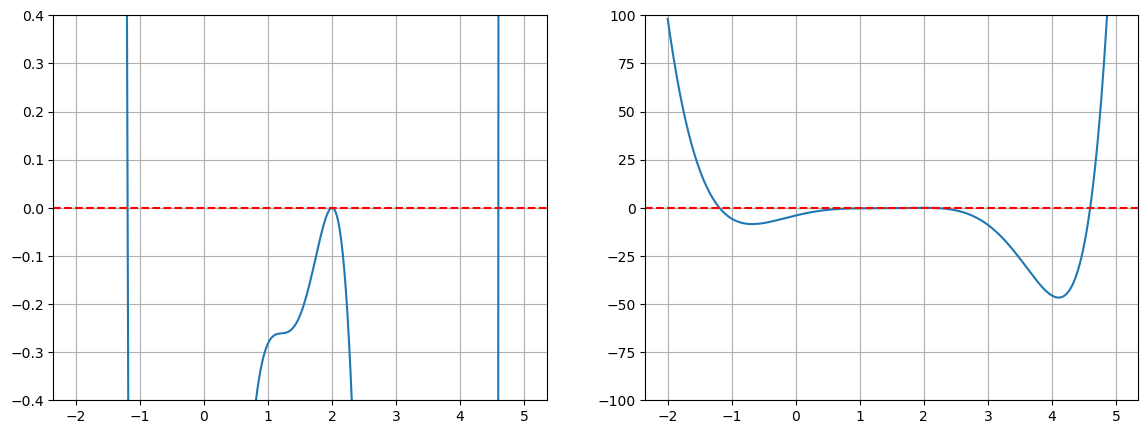

In [2]:
def f(x):
    return (x - 2) ** 2 * (np.exp(x) - x ** 3 - 2)

x = np.linspace(-2,5,300)

fig, fx = plt.subplots(1,2,figsize=(14,5))
fx[0].plot(x,f(x))
fx[0].axhline(y=0, color='red', linestyle='--')
fx[0].set_ylim(-0.4,0.4)
fx[0].grid(True)
fx[1].plot(x, f(x))
fx[1].set_ylim(-100,100)
fx[1].axhline(y=0, color='red', linestyle='--')
fx[1].grid(True)

# Roots are x=2, and x = about -1.2 and 4.5.

In [3]:
#Fixed-Poimt Method

def g(x):
  return f(x) + x

def fixedpoint(g, xold, kmax=100, tol=1e-8, text=False):
  past_k = []
  past_x = []

  for k in range(1,kmax):
    xnew = g(xold)
      
    if np.isnan(xnew) or np.isinf(xnew):
      print("Encountered NaN or Infinity. Stopping.")
      xnew = None
      break
    
    error = xnew - xold
    if text: print("{0:2d} {1:1.16f} {2:1.16f} {3:1.16f}".format(k,xnew, error, g(xnew)))
    
    past_k.append(k)
    past_x.append(xnew)
    
    if np.abs(error) < tol:
      break
    
    xold = xnew
    
  else:
    print("Maximum iterations reached without convergence.")
    xnew = None
  return xnew, np.array(past_k), np.array(past_x)

for x0 in (-1, 2.001, 4.5):
  root, past_k, past_x = fixedpoint(g, x0, text=True)
  print(root,"\n")

 1 -6.6890850294570185 -5.6890850294570185 22439.2722332548291888
 2 22439.2722332548291888 22445.9613182842876995 inf
Encountered NaN or Infinity. Stopping.
None 

 1 2.0009973844428495 -0.0000026155571504 2.0009947825620933
 2 2.0009947825620933 -0.0000026018807562 2.0009921942505882
 3 2.0009921942505882 -0.0000025883115051 2.0009896194023078
 4 2.0009896194023078 -0.0000025748482804 2.0009870579123290
 5 2.0009870579123290 -0.0000025614899788 2.0009845096768175
 6 2.0009845096768175 -0.0000025482355115 2.0009819745930133
 7 2.0009819745930133 -0.0000025350838042 2.0009794525592168
 8 2.0009794525592168 -0.0000025220337965 2.0009769434747762
 9 2.0009769434747762 -0.0000025090844407 2.0009744472400728
10 2.0009744472400728 -0.0000024962347034 2.0009719637565078
11 2.0009719637565078 -0.0000024834835650 2.0009694929264898
12 2.0009694929264898 -0.0000024708300179 2.0009670346534221
13 2.0009670346534221 -0.0000024582730678 2.0009645888416898
14 2.0009645888416898 -0.0000024458117323 

/tmp/ipykernel_108683/3052742309.py:2: RuntimeWarning: overflow encountered in exp
  return (x - 2) ** 2 * (np.exp(x) - x ** 3 - 2)


In [4]:
#Bisection Method

def bisection(f, x0, x1, kmax=100, tol=1e-8, text=False):
  past_k = []
  past_x = []
  f0 = f(x0)
  f1 = f(x1)

  if f0 * f1 > 0:
    print("Error: Function must have opposite signs at the endpoints (not bracketed).")
    return None, None, None

  x2old = x0
  for k in range(1, kmax):
    x2 = (x0 + x1) / 2
    f2 = f(x2)

    if f0 * f2 < 0:
      x1 = x2
    else:
      x0 = x2
      f0 = f2

    error = (x1 - x0) / 2
    rowf = "{0:2d} {1:1.16f} {2:1.16f} {3:1.16f}"
    if text: print(rowf.format(k, x2, error, abs(f2)))
    past_k.append(k)
    past_x.append(x2)
      
    if error < tol:
      break
    
  else:
    print("Maximum iterations reached without convergence.")
    x2 = None
  return x2, np.array(past_k), np.array(past_x)

for x0, x1 in ((-2, 2), (1, 3), (4, 5)):
  root, past_k, past_x = bisection(f, x0, x1, text=True)
  print(root,"\n")

 1 0.0000000000000000 1.0000000000000000 4.0000000000000000
 2 -1.0000000000000000 0.5000000000000000 5.6890850294570185
 3 -1.5000000000000000 0.2500000000000000 19.5770944618182661
 4 -1.2500000000000000 0.1250000000000000 2.5310897293357586
 5 -1.1250000000000000 0.0625000000000000 2.4562442152504906
 6 -1.1875000000000000 0.0312500000000000 0.2078431100025768
 7 -1.2187500000000000 0.0156250000000000 1.0968675370279037
 8 -1.2031250000000000 0.0078125000000000 0.4287620725555524
 9 -1.1953125000000000 0.0039062500000000 0.1065760130030119
10 -1.1914062500000000 0.0019531250000000 0.0515977058665035
11 -1.1933593750000000 0.0009765625000000 0.0272472776810276
12 -1.1923828125000000 0.0004882812500000 0.0122355783610515
13 -1.1928710937500000 0.0002441406250000 0.0074907455134341
14 -1.1926269531250000 0.0001220703125000 0.0023761908249843
15 -1.1927490234375000 0.0000610351562500 0.0025563335395330
16 -1.1926879882812500 0.0000305175781250 0.0000898354316528
17 -1.1926574707031250 0

$$
f'(x) = -5x^4 + 16x^3 + x^2 e^x - 12x^2 - 2x e^x - 4x + 8
$$
$$
f'(x) = (x - 2)(x e^x - 5x^3 + 6x^2 - 4)
$$

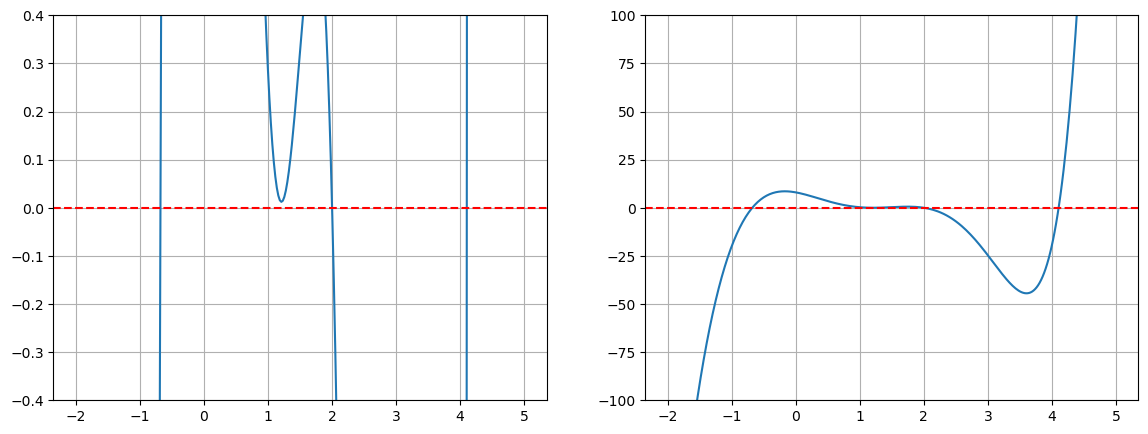

In [5]:
def df(x):
    return (x - 2) * (x * np.exp(x) - 5 * x ** 3 + 6 * x ** 2 - 4)

x = np.linspace(-2,5,300)

fig, dfx = plt.subplots(1,2,figsize=(14,5))
dfx[0].plot(x,df(x))
dfx[0].axhline(y=0, color='red', linestyle='--')
dfx[0].set_ylim(-0.4,0.4)
dfx[0].grid(True)
dfx[1].plot(x, df(x))
dfx[1].set_ylim(-100,100)
dfx[1].axhline(y=0, color='red', linestyle='--')
dfx[1].grid(True)

In [6]:
#Newton's Method

def newton(f, df, x0, kmax=100, tol=1e-8, text = False):
  past_k = []
  past_x = []
  xold = x0
    
  for k in range(1, kmax):
    if df(xold) == 0 or np.isnan(df(xold)) or np.isinf(df(xold)):
      print("Derivative is zero. Stopping.")
      return None, None, None

    xnew = xold - f(xold) / df(xold)

    if np.isnan(xnew) or np.isinf(xnew):
      print("Encountered NaN or Infinity. Stopping.")
      return None, None, None

    error = xnew - xold
    rowf = "{0:2d} {1:1.16f} {2:1.16f} {3:1.16f}"
    if text: print(rowf.format(k, xnew, error, np.abs(f(xnew))))
    past_k.append(k)
    past_x.append(xnew)

    if np.abs(error) < tol:
      break

    xold = xnew
  else:
    print("Maximum iterations reached without convergence.")
    xnew = None
  return xnew, np.array(past_k), np.array(past_x)
    
# The should give the error if x=2 or x = somewhere near 4 and -1 (based from graph of df) since df(x) = 0.

for x0 in (2, 1.5, 5, -2):
  root, past_k, past_x = newton(f, df, x0, text=True)
  print(root,"\n")

Derivative is zero. Stopping.
None 

 1 2.1845647049425567 0.6845647049425567 0.1205416798008912
 2 2.1037294301227600 -0.0808352748197967 0.0335032687382545
 3 2.0559111832839791 -0.0478182468387809 0.0089902708155934
 4 2.0292182715478213 -0.0266929117361578 0.0023456719653727
 5 2.0149686449693318 -0.0142496265784895 0.0006005890726366
 6 2.0075808568863578 -0.0073877880829740 0.0001520658019262
 7 2.0038154876245482 -0.0037653692618096 0.0000382665861838
 8 2.0019141309576245 -0.0019013566669237 0.0000095985986888
 9 2.0009586780040451 -0.0009554529535793 0.0000024036878655
10 2.0004797441295050 -0.0004789338745401 0.0000006014295454
11 2.0002399735979779 -0.0002397705315271 0.0000001504210104
12 2.0001200122138303 -0.0001199613841476 0.0000000376132167
13 2.0000600124645747 -0.0000599997492556 0.0000000094043004
14 2.0000300078221964 -0.0000300046423782 0.0000000023511997
15 2.0000150043086373 -0.0000150035135591 0.0000000005878155
16 2.0000075022537112 -0.0000075020549262 0.00000

In [7]:
#Secant Method

def secant(f, x0, x1, kmax=100, tol=1e-8, text=False):
  past_k = []
  past_x = []

  for k in range(1, kmax):
    f0 = f(x0)
    f1 = f(x1)

    if f1 - f0 == 0 or np.isnan(f1 - f0) or np.isinf(f1 - f0):
      print("Division by zero or invalid denominator. Stopping.")
      return None, None, None

    x2 = x1 - f1 * (x1 - x0) / (f1 - f0)

    if np.isnan(x2) or np.isinf(x2):
      print("Encountered NaN or Infinity. Stopping.")
      return None, None, None

    error = np.abs(x2 - x1)

    rowf = "{0:2d} {1:1.16f} {2:1.16f} {3:1.16f}"
    if text: print(rowf.format(k, x2, error, np.abs(f(x2))))
    past_k.append(k)
    past_x.append(x2)

    if error < tol:
      break

    x0 = x1
    x1 = x2
  else:
    print("Maximum iterations reached without convergence.")
    x2 = None
  return x2, np.array(past_k), np.array(past_x)

for x0, x1 in ((-2, -1), (1.95, 2.1), (4, 5)):
  root, past_k, past_x = secant(f, x0, x1, text=True)
  print(root,"\n")

 1 -1.0547794057307307 0.0547794057307307 4.4626488659683332
 2 -1.2541059260506118 0.1993265203198811 2.7295334975425649
 3 -1.1784587321026367 0.0756471939479750 0.5621599400134721
 4 -1.1913778640991919 0.0129191319965551 0.0527400477165098
 5 -1.1927153769216339 0.0013375128224420 0.0011965822895655
 6 -1.1926857042454726 0.0000296726761613 0.0000024558185427
 7 -1.1926857650197782 0.0000000607743056 0.0000000001139712
 8 -1.1926857650225988 0.0000000000028206 0.0000000000000000
-1.1926857650225988 

 1 1.9141825926456286 0.1858174073543715 0.0164404517114401
 2 1.7036122952530843 0.2105702973925443 0.1274314375621277
 3 1.9453731508663010 0.2417608556132167 0.0070602955604027
 4 1.9595534856806096 0.0141803348143086 0.0039723967863856
 5 1.9777956369195733 0.0182421512389637 0.0012373667590181
 6 1.9860486474277619 0.0082530105081886 0.0004957612131229
 7 1.9915657616458289 0.0055171142180670 0.0001829782855588
 8 1.9947932782776201 0.0032275166317912 0.0000701334037102
 9 1.99679

Maximum iterations reached without convergence.


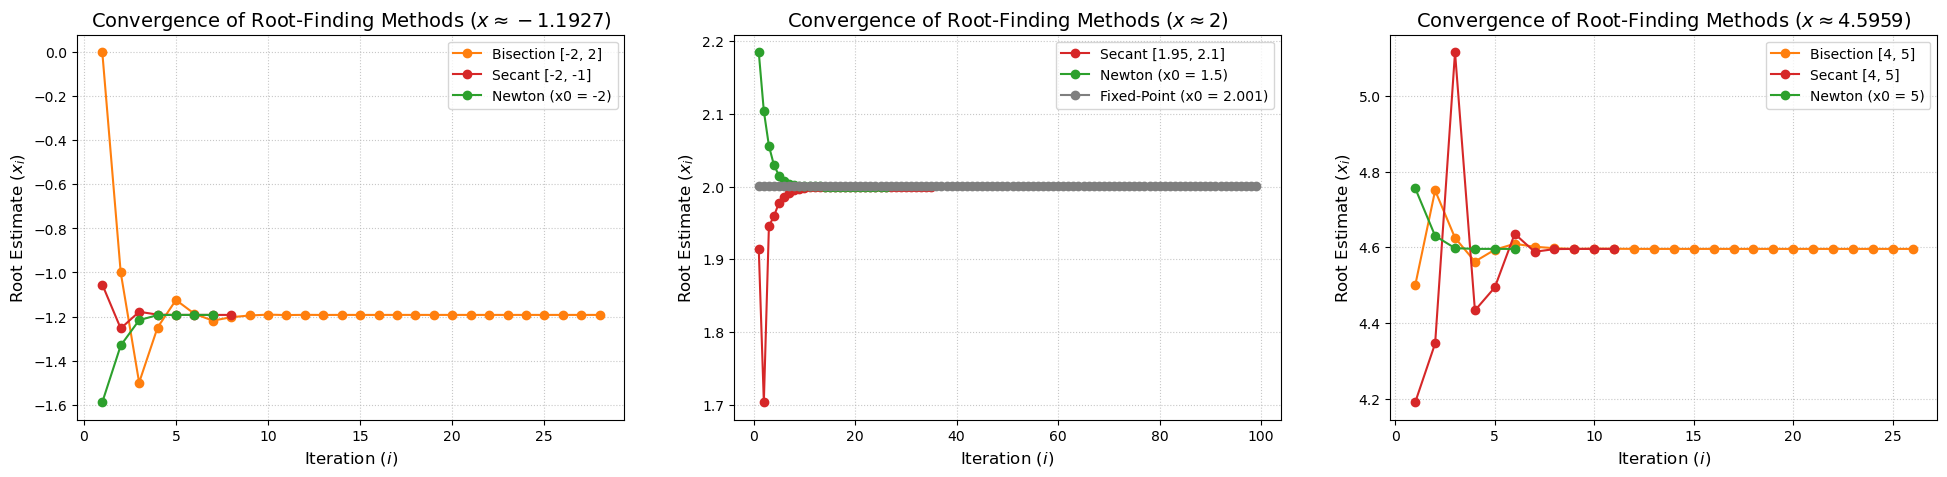

In [8]:
exp1 = [
    ("Bisection [-2, 2]", bisection(f, -2, 2)),
    ("Secant [-2, -1]", secant(f, -2, -1)),\
    ("Newton (x0 = -2)", newton(f, df, -2)),
]
exp2 = [
    ("Secant [1.95, 2.1]", secant(f, 1.95, 2.1)),
    ("Newton (x0 = 1.5)", newton(f, df, 1.5)),
    ("Fixed-Point (x0 = 2.001)", fixedpoint(g, 2.001)),
]
exp3 = [
    ("Bisection [4, 5]", bisection(f, 4, 5)),
    ("Secant [4, 5]", secant(f, 4, 5)),
    ("Newton (x0 = 5)", newton(f, df, 5)),
]
color_map = {
    "Bisection": "tab:orange",
    "Secant": "tab:red",
    "Newton": "tab:green",
    "Fixed-Point": "tab:gray",
}

fig, ex = plt.subplots(1, 3, figsize=(24, 5))
for label, result in exp1:
  if result is not None:
    root, past_k, past_x = result
    if past_k is not None and len(past_k) > 0:
      color = next((c for k, c in color_map.items() if k in label), "tab:gray")
      ex[0].plot(past_k, past_x, marker="o", linestyle="-", label=label, color=color)
ex[0].set_xlabel("Iteration ($i$)", fontsize=12)
ex[0].set_ylabel("Root Estimate ($x_i$)", fontsize=12)
ex[0].set_title(r"Convergence of Root-Finding Methods ($x\approx-1.1927$)", fontsize=14)
ex[0].legend()
ex[0].grid(True, linestyle=":", alpha=0.7)
for label, result in exp2:
  if result is not None:
    root, past_k, past_x = result
    if past_k is not None and len(past_k) > 0:
      color = next((c for k, c in color_map.items() if k in label), "tab:gray")
      ex[1].plot(past_k, past_x, marker="o", linestyle="-", label=label, color=color)
ex[1].set_xlabel("Iteration ($i$)", fontsize=12)
ex[1].set_ylabel("Root Estimate ($x_i$)", fontsize=12)
ex[1].set_title(r"Convergence of Root-Finding Methods ($x\approx2$)", fontsize=14)
ex[1].legend()
ex[1].grid(True, linestyle=":", alpha=0.7)
for label, result in exp3:
  if result is not None:
    root, past_k, past_x = result
    if past_k is not None and len(past_k) > 0:
      color = next((c for k, c in color_map.items() if k in label), "tab:gray")
      ex[2].plot(past_k, past_x, marker="o", linestyle="-", label=label, color=color)
ex[2].set_xlabel("Iteration ($i$)", fontsize=12)
ex[2].set_ylabel("Root Estimate ($x_i$)", fontsize=12)
ex[2].set_title(r"Convergence of Root-Finding Methods ($x\approx4.5959$)", fontsize=14)
ex[2].legend()
ex[2].grid(True, linestyle=":", alpha=0.7)

#### Problem 1 code summary

The script show various root-finding techniques and graphs their convergence. Since some methods are limited to specific roots (i.e. fixed-point iteration finding only the root at x = 2), I find find all of the discoverable roots and graphs the convergence for those successful values.

---